In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:

# =========================
# Load CIFAR-10 Dataset
# =========================
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0



In [3]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [4]:

# =========================
# Data Augmentation
# =========================
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train)



In [5]:

# =========================
# CNN Model
# =========================
model = models.Sequential([

    # Block 1
    layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64,(3,3),padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])



c:\Users\mishr\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:

# =========================
# Compile Model
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:


# =========================
# Train Model
# =========================
history = model.fit(
    datagen.flow(x_train,y_train,batch_size=64),
    epochs=10,
    validation_data=(x_test,y_test)
)



Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 170ms/step - accuracy: 0.3561 - loss: 1.7318 - val_accuracy: 0.5001 - val_loss: 1.3791
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 128s 163ms/step - accuracy: 0.4819 - loss: 1.4270 - val_accuracy: 0.4953 - val_loss: 1.3540
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 134s 172ms/step - accuracy: 0.5358 - loss: 1.3019 - val_accuracy: 0.5739 - val_loss: 1.1899
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 177ms/step - accuracy: 0.5738 - loss: 1.2081 - val_accuracy: 0.5758 - val_loss: 1.1706
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 137s 175ms/step - accuracy: 0.5966 - loss: 1.1434 - val_accuracy: 0.6621 - val_loss: 0.9628
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 130s 166ms/step - accuracy: 0.6177 - loss: 1.0892 - val_accuracy: 0.6798 - val_loss: 0.9017
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 129s 165ms/step - accuracy: 0.6349 - loss: 1.0414 - val_accuracy: 0.6510 - val_loss: 0.9882
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 136s 174ms/step - accuracy: 0.6457 -

In [10]:

# =========================
# Evaluate Model
# =========================
test_loss, test_acc = model.evaluate(x_test,y_test)

print("Test Accuracy:", test_acc)



313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7000 - loss: 0.8427
Test Accuracy: 0.699999988079071


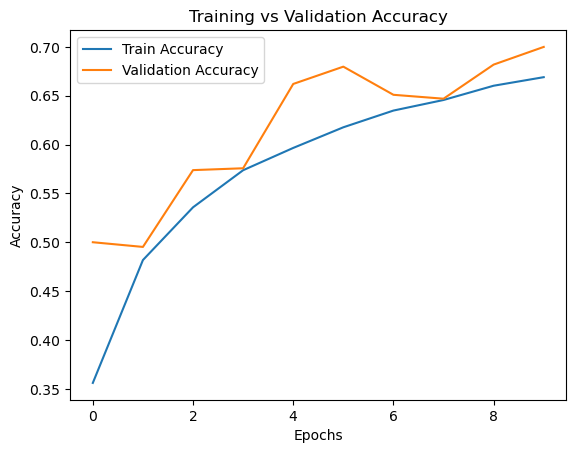

In [11]:

# =========================
# Plot Accuracy
# =========================
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

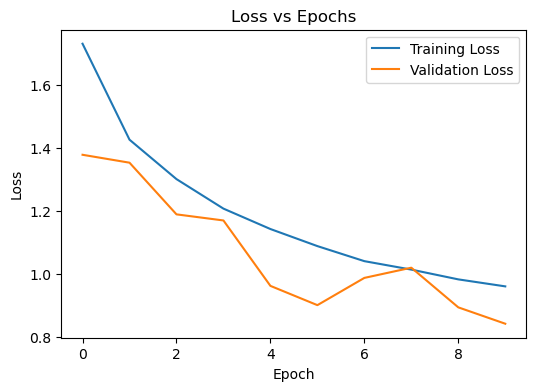

In [12]:
# Loss Graph

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()